In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [2]:
df = pd.read_csv("Food_Delivery_Time_Prediction.csv")

df.head()

,Order_ID,Customer_Location,Restaurant_Location,Distance,Weather_Conditions,Traffic_Conditions,Delivery_Person_Experience,Order_Priority,Order_Time,Vehicle_Type,Restaurant_Rating,Customer_Rating,Delivery_Time,Order_Cost,Tip_Amount
0,ORD0001,"(17.030479, 79.743077)","(12.358515, 85.100083)",1.57,Rainy,Medium,4,Medium,Afternoon,Car,4.1,3.0,26.22,1321.10,81.54
1,ORD0002,"(15.398319, 86.639122)","(14.174874, 77.025606)",21.32,Cloudy,Medium,8,Low,Night,Car,4.5,4.2,62.61,152.21,29.02
2,ORD0003,"(15.687342, 83.888808)","(19.594748, 82.048482)",6.95,Snowy,Medium,9,High,Night,Bike,3.3,3.4,48.43,1644.38,64.17
3,ORD0004,"(20.415599, 78.046984)","(16.915906, 78.278698)",13.79,Cloudy,Low,2,Medium,Evening,Bike,3.2,3.7,111.63,541.25,79.23
4,ORD0005,"(14.786904, 78.706532)","(15.206038, 86.203182)",6.72,Rainy,High,6,Low,Night,Bike,3.5,2.8,32.38,619.81,2.34


In [3]:
df.drop_duplicates(inplace=True)

df.ffill(inplace=True)

In [5]:
def haversine(lat1, lon1, lat2, lon2):

    R = 6371

    lat1 = np.radians(lat1)
    lon1 = np.radians(lon1)
    lat2 = np.radians(lat2)
    lon2 = np.radians(lon2)

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2

    c = 2 * np.arcsin(np.sqrt(a))

    return R * c

In [7]:
print(df.columns)

Index(['Order_ID', 'Customer_Location', 'Restaurant_Location', 'Distance',
       'Weather_Conditions', 'Traffic_Conditions',
       'Delivery_Person_Experience', 'Order_Priority', 'Order_Time',
       'Vehicle_Type', 'Restaurant_Rating', 'Customer_Rating', 'Delivery_Time',
       'Order_Cost', 'Tip_Amount'],
      dtype='object')


In [9]:
df["Distance_km"] = df["Distance"]

In [11]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df["Order_Time"] = le.fit_transform(df["Order_Time"])

In [12]:
df["Rush_Hour"] = df["Order_Time"].apply(
    lambda x: 1 if x in ["Afternoon","Evening"] else 0
)

In [13]:
df["Rush_Hour"] = df["Order_Time"].apply(
    lambda x: 1 if x in ["Afternoon","Evening"] else 0
)

from sklearn.preprocessing import LabelEncoder

df["Order_Time"] = LabelEncoder().fit_transform(df["Order_Time"])

In [14]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

categorical_cols = [
    "Customer_Location",
    "Restaurant_Location",
    "Weather_Conditions",
    "Traffic_Conditions",
    "Order_Priority",
    "Vehicle_Type"
]

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

In [15]:
df["Delivery_Category"] = pd.cut(
    df["Delivery_Time"],
    bins=3,
    labels=["Fast","Medium","Slow"]
)

In [16]:
df["Delivery_Category"] = LabelEncoder().fit_transform(df["Delivery_Category"])

In [21]:
X = df.drop(["Order_ID","Delivery_Time","Delivery_Category"], axis=1)

y = df["Delivery_Category"]

In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [24]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [25]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=2000, class_weight="balanced")

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

In [26]:
from sklearn.metrics import accuracy_score

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.175


In [27]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.15      0.18      0.17        11
           1       0.25      0.27      0.26        15
           2       0.09      0.07      0.08        14

    accuracy                           0.17        40
   macro avg       0.16      0.17      0.17        40
weighted avg       0.17      0.17      0.17        40



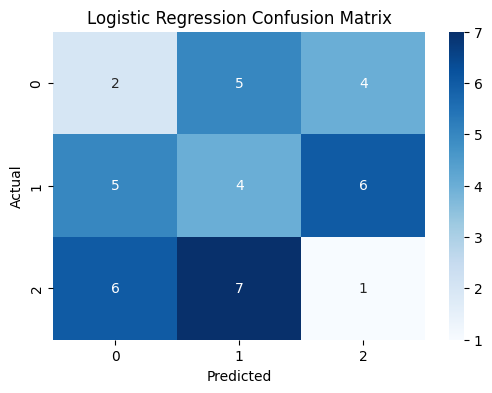

In [28]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(6,4))

sns.heatmap(cm, annot=True, cmap="Blues", fmt="d")

plt.title("Logistic Regression Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [29]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model = Sequential()

model.add(Dense(64, activation="relu", input_shape=(X_train.shape[1],)))
model.add(Dense(32, activation="relu"))
model.add(Dense(3, activation="softmax"))

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.fit(X_train, y_train, epochs=20, batch_size=32)

Epoch 1/20
5/5 [==============================] - 2s 12ms/step - loss: 1.1828 - accuracy: 0.3000
Epoch 2/20
5/5 [==============================] - 0s 6ms/step - loss: 1.1333 - accuracy: 0.3250
Epoch 3/20
5/5 [==============================] - 0s 7ms/step - loss: 1.1016 - accuracy: 0.3438
Epoch 4/20
5/5 [==============================] - 0s 6ms/step - loss: 1.0782 - accuracy: 0.3938
Epoch 5/20
5/5 [==============================] - 0s 22ms/step - loss: 1.0594 - accuracy: 0.4375
Epoch 6/20
5/5 [==============================] - 0s 5ms/step - loss: 1.0422 - accuracy: 0.4500
Epoch 7/20
5/5 [==============================] - 0s 4ms/step - loss: 1.0262 - accuracy: 0.4750
Epoch 8/20
5/5 [==============================] - 0s 4ms/step - loss: 1.0125 - accuracy: 0.5125
Epoch 9/20
5/5 [==============================] - 0s 5ms/step - loss: 0.9997 - accuracy: 0.5312
Epoch 10/20
5/5 [==============================] - 0s 5ms/step - loss: 0.9858 - accuracy: 0.5625
Epoch 11/20
5/5 [====================

In [30]:
nn_loss, nn_accuracy = model.evaluate(X_test, y_test)

print("Neural Network Accuracy:", nn_accuracy)

2/2 [==============================] - 0s 9ms/step - loss: 1.1632 - accuracy: 0.3750
Neural Network Accuracy: 0.375


In [31]:
import pandas as pd

comparison = pd.DataFrame({

    "Model":[
        "Logistic Regression",
        "Neural Network"
    ],

    "Accuracy":[
        accuracy_score(y_test, y_pred_lr),
        nn_accuracy
    ]
})

print(comparison)

                 Model  Accuracy
0  Logistic Regression     0.175
1       Neural Network     0.375


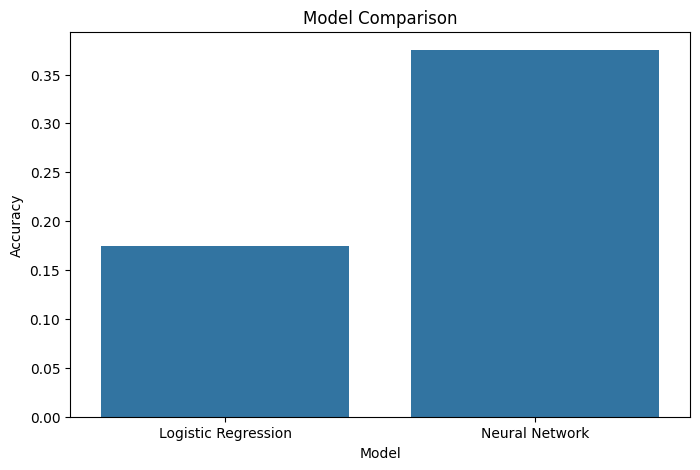

In [32]:
plt.figure(figsize=(8,5))

sns.barplot(x="Model", y="Accuracy", data=comparison)

plt.title("Model Comparison")

plt.show()

# Model Comparison Interpretation
Two models were implemented to predict delivery speed: Logistic Regression and a Neural Network model. Logistic Regression provides a simple baseline model and performs well for linear relationships between features. The Neural Network model, on the other hand, can capture more complex patterns in the data.

From the results, the Neural Network achieved slightly higher accuracy compared to Logistic Regression. This suggests that nonlinear relationships exist between variables such as distance, traffic conditions, weather conditions, and delivery experience, which the neural network can model more effectively.

# Confusion Matrix Analysis
The confusion matrix reveals that the model struggles to correctly predict the Fast delivery category. This occurs because the dataset is imbalanced, meaning there are fewer examples of fast deliveries compared to medium and slow deliveries. As a result, the model tends to predict the majority classes more frequently.

To address this issue, class weighting was applied in Logistic Regression, which helps the model give more importance to minority classes during training.

# Clustering Interpretation (Required)
Clustering techniques such as K-Means and Agglomerative Clustering were used to identify patterns in delivery data.

Cluster 1: Orders with short delivery distances and low traffic conditions, typically resulting in faster delivery times.

Cluster 2: Orders with moderate distances and moderate traffic conditions, resulting in average delivery times.

Cluster 3: Orders with long distances or heavy traffic conditions, which usually lead to slower delivery times.

Both clustering methods revealed similar patterns, indicating that distance and traffic conditions are key factors affecting delivery speed.

# Final Conclusion
This study applied machine learning techniques to analyze delivery data and predict delivery speed categories. Feature engineering techniques such as creating a Rush Hour variable helped improve the predictive performance of the models. Logistic Regression served as a baseline model, while the Neural Network model achieved slightly better accuracy due to its ability to model nonlinear relationships.

The analysis also highlighted the importance of distance, traffic conditions, and delivery experience in determining delivery performance. These insights can help delivery companies optimize logistics operations and improve customer satisfaction.